<!-- @format -->

# Adult Income Predition - Deep Learning Pipeline

Xây dựng pipeline Deep Learning hoàn chỉnh cho bài toán phân loại thu nhập trên tập dữ liệu Adult Census.

**Pipeline gồm các bước:**

1. Tổng quan dữ liệu
2. Tiền xử lí dữ liệu
4. Huấn luyện mô hình
5. Đánh giá & so sánh tổng hợp


<!-- @format -->

## 1. Tổng quan dữ liệu

Phần này tóm tắt nhanh đặc trưng dữ liệu, phân phối target và các đặc trưng quan trọng nhất, giúp định hướng cho pipeline deep learning.


In [1]:
# Import thư viện và load dữ liệu
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import modules.eda as eda

import modules.deep_learning as dl

url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = eda.load_data(url)


Dataset shape: (48842, 15)
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-pe

In [2]:
# Tổng quan nhanh dữ liệu
eda.dataset_overview(df)
num_cols, cat_cols = eda.get_column_types(df)


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

=== Numerical Summary ===
                age       

In [3]:
# Kiểm tra missing value và giá trị bất thường
eda.check_missing_values(df)
eda.inspect_categorical_values(df, cat_cols)


=== Missing values (NaN) ===
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

=== '?' count per column ===
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Column: workclass  |  unique: 9
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay    

<!-- @format -->

**Nhận xét:** Một số cột phân loại có giá trị '?' thay cho missing value. Cần chuẩn hóa về NaN trước khi xử lý tiếp.


Unique values: ['<=50K' '>50K']

Class counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Class percentages (%):
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


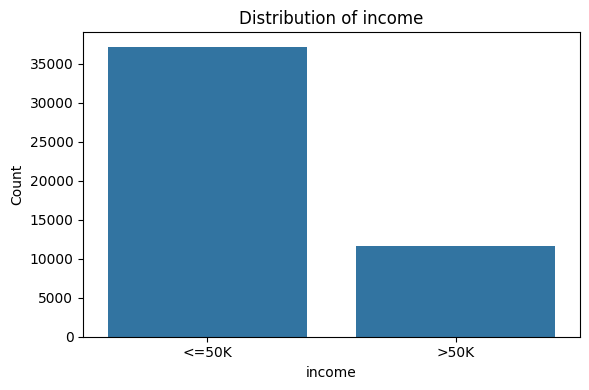

In [4]:
# Phân phối biến mục tiêu (income)
eda.plot_target_distribution(df, target_col='income')

<!-- @format -->

**Nhận xét:** Dữ liệu có mất cân bằng nhẹ giữa hai lớp thu nhập (>50K và <=50K), cần lưu ý khi đánh giá mô hình. Nhóm dự định sẽ sử dụng phương pháp SMOTE để cân bằng lại số lượng của 2 lớp này giúp tránh overfitting đối với người có income >50k.


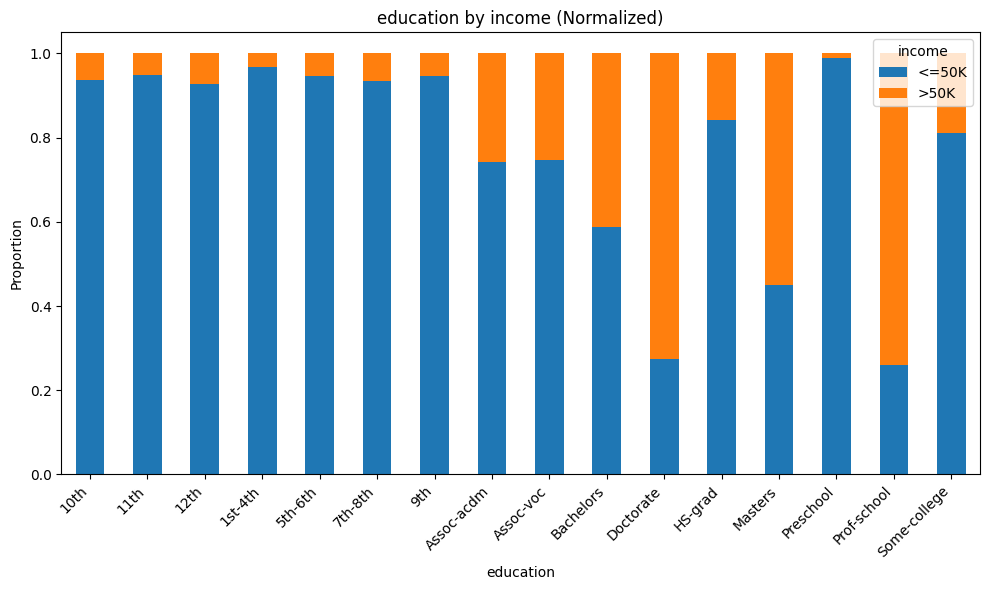

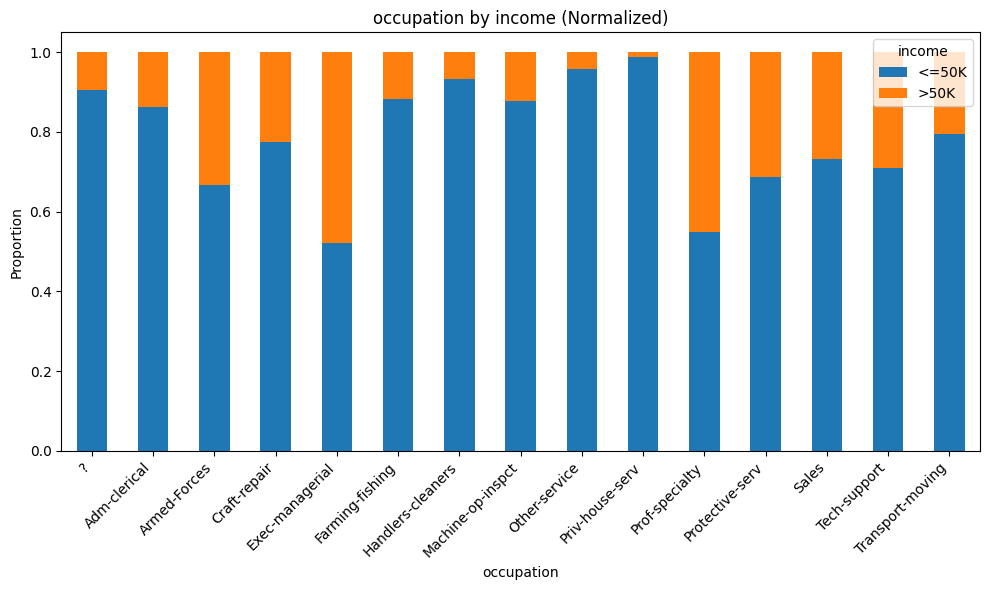

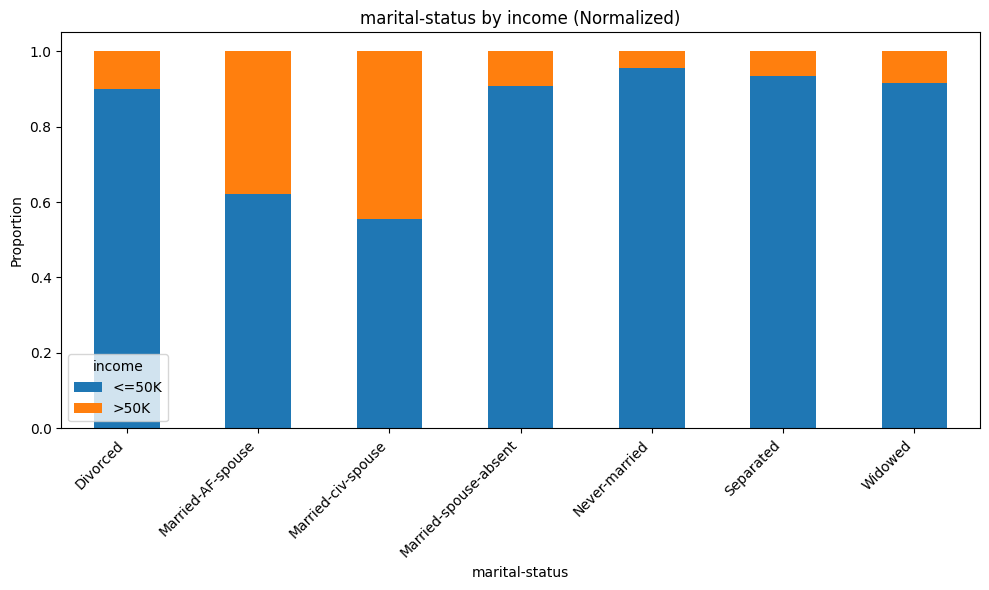

In [5]:
# Phân tích nhanh một số biến phân loại tiêu biểu
top_cat = ['education', 'occupation', 'marital-status']
eda.plot_categorical_by_target(df, top_cat, target_col='income')

<!-- @format -->

**Nhận xét:** Một số biến phân loại như education, occupation, marital-status có sự khác biệt rõ rệt giữa hai nhóm thu nhập.


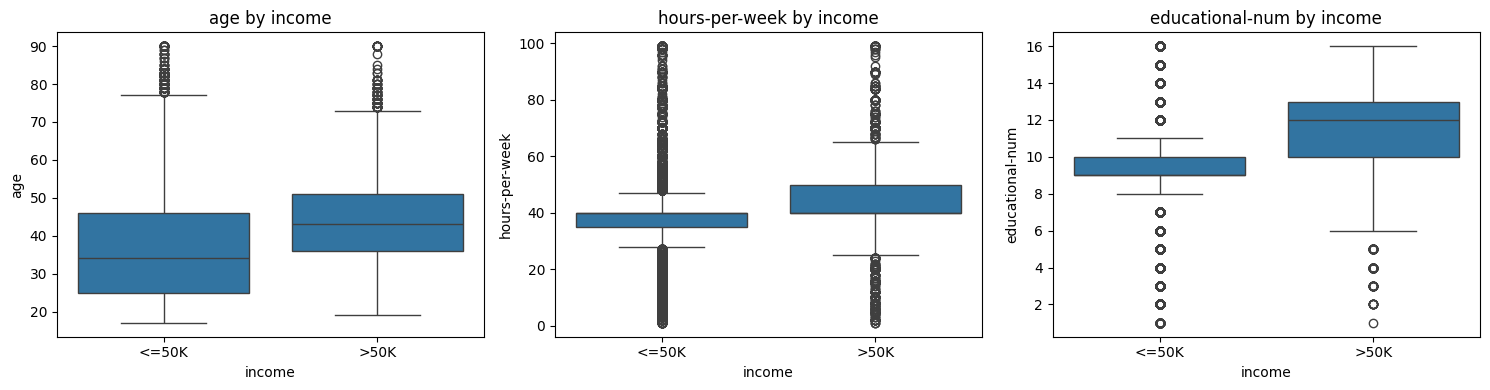

In [6]:
# Phân tích nhanh các biến số quan trọng
num_cols_sel = ['age', 'hours-per-week', 'educational-num']
eda.plot_numerical_by_target(df, num_cols_sel, target_col='income')


<!-- @format -->

**Nhận xét:** Các biến số như age, hours-per-week, educational-num đều có sự khác biệt phân phối giữa hai nhóm thu nhập.


=== capital-gain ===
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

Zero values : 44807 (91.74%)
Non-zero    : 4035 (8.26%)

Proportion of non-zero capital-gain by income:
capital-gain  False  True 
income                    
<=50K         0.958  0.042
>50K          0.787  0.213


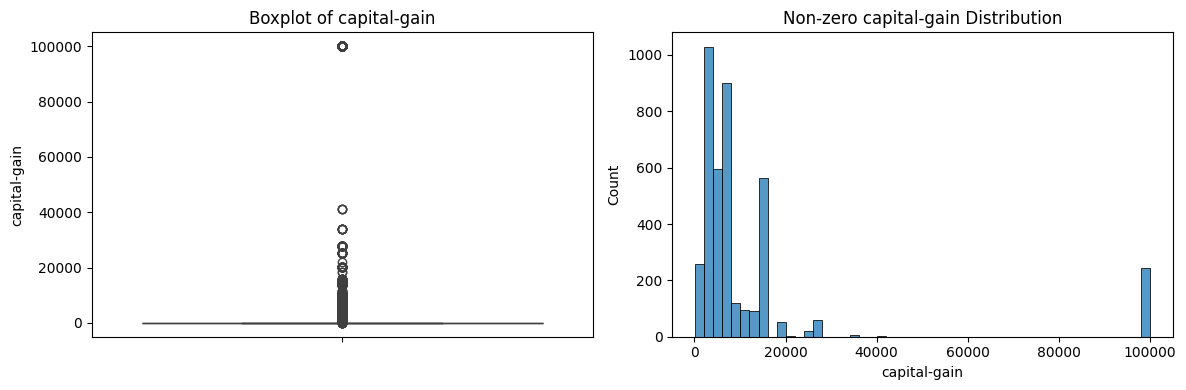

=== capital-loss ===
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Zero values : 46560 (95.33%)
Non-zero    : 2282 (4.67%)

Proportion of non-zero capital-loss by income:
capital-loss  False  True 
income                    
<=50K         0.969  0.031
>50K          0.902  0.098


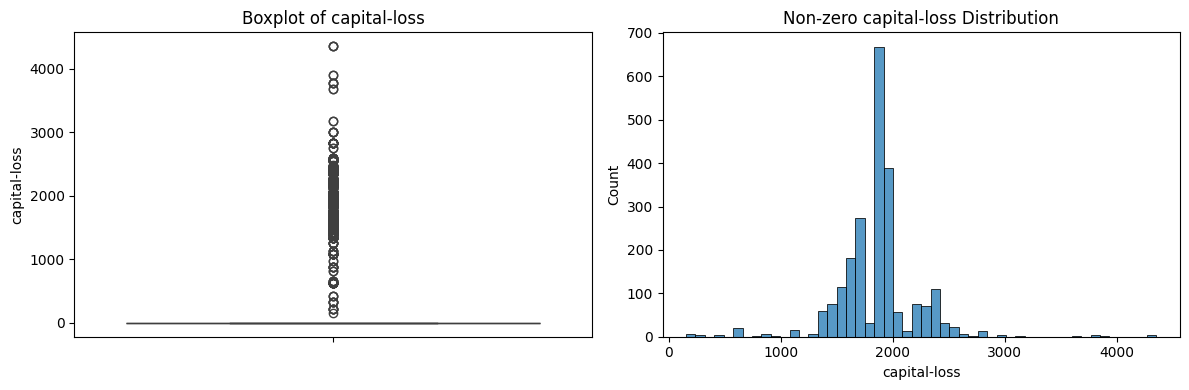

In [7]:
# Phân tích phân phối và ý nghĩa của capital-gain, capital-loss
eda.analyze_capital_feature(df, 'capital-gain', target_col='income')
eda.analyze_capital_feature(df, 'capital-loss', target_col='income')


<!-- @format -->

**Nhận xét:** Cả hai biến capital-gain và capital-loss đều có phân phối rất lệch, nhiều giá trị 0, nhưng tỷ lệ giá trị khác 0 ở nhóm >50K cao hơn đáng kể. Đây là đặc trưng hữu ích cho mô hình.


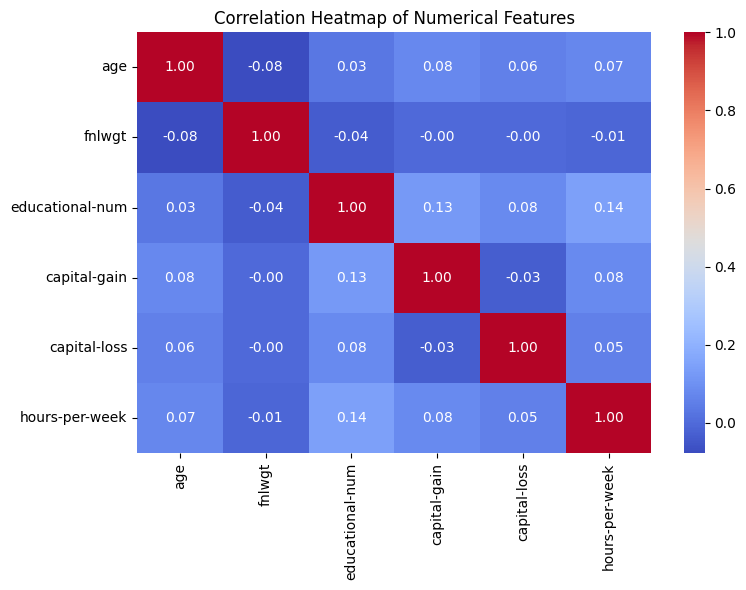

In [8]:
# Heatmap tương quan các biến số
eda.plot_correlation_heatmap(df, num_cols)


<!-- @format -->

**Nhận xét:** Các biến số không có cặp nào tương quan quá cao, có thể giữ lại hầu hết cho mô hình.


In [9]:
# Kiểm tra trùng lặp thông tin education & educational-num
eda.check_education_redundancy(df)

Mapping between education and educational-num:
       education educational-num
0           10th             [6]
1           11th             [7]
2           12th             [8]
3        1st-4th             [2]
4        5th-6th             [3]
5        7th-8th             [4]
6            9th             [5]
7     Assoc-acdm            [12]
8      Assoc-voc            [11]
9      Bachelors            [13]
10     Doctorate            [16]
11       HS-grad             [9]
12       Masters            [14]
13     Preschool             [1]
14   Prof-school            [15]
15  Some-college            [10]


<!-- @format -->

**Nhận xét:** Hai cột education và educational-num gần như mang cùng thông tin, có thể cân nhắc chỉ giữ lại một trong hai khi xây dựng mô hình.


<!-- @format -->

# 2. Tiền xử lí dữ liệu


<!-- @format -->
## 2.1. Import preprocessing module

In [10]:
import importlib
import modules.preprocessing as prep_module
importlib.reload(prep_module)

from modules.preprocessing import (
    drop_columns,
    drop_missing_values,
    map_target_variable,
    apply_ohe,
    scale_numeric,
    split_data,
    apply_smote,
)

<!-- @format -->
## 2.2. Làm sạch dữ liệu

Các bước:
1. **Xoá cột dư thừa**: `education` (trùng thông tin với `educational-num`) và `fnlwgt` (trọng số thống kê, không liên quan phân loại).
2. **Xử lý giá trị `?`**: thay bằng `NaN` rồi xoá các hàng thiếu.
3. **Mã hoá biến mục tiêu**: `<=50K` → 0, `>50K` → 1.

In [11]:
df_clean = df.copy()

# 1. Xoá cột dư thừa
df_clean = drop_columns(df_clean, columns=['education', 'fnlwgt'])

# 2. Xử lý missing value ('?' → NaN → drop row)
df_clean = drop_missing_values(df_clean)

# 3. Mã hoá biến mục tiêu
df_clean = map_target_variable(df_clean, target_col='income')

print(f"\nKích thước sau làm sạch: {df_clean.shape}")
df_clean.head()

Dropped columns: ['education', 'fnlwgt']
Dropped rows with missing values: 3620
Mapped target variable 'income' to binary.

Kích thước sau làm sạch: (45222, 13)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


<!-- @format -->
## 2.3. Xác định loại đặc trưng

In [12]:
TARGET_COL = 'income'

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Bỏ target khỏi danh sách (nếu có)
if TARGET_COL in num_cols: num_cols.remove(TARGET_COL)
if TARGET_COL in cat_cols: cat_cols.remove(TARGET_COL)

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Numerical features (5): ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (7): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


<!-- @format -->
## 2.4. Chia dữ liệu Train / Val / Test

Split **trước** khi encode & scale để tránh data leakage.
Tỉ lệ: **70% train – 10% val – 20% test** (stratify theo `income`).

In [13]:
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(
    df_clean,
    target_col=TARGET_COL,
    test_size=0.2,
    val_size=0.1,
    random_state=42,
)

Split data → Train: 31654, Val: 4523, Test: 9045
  Class dist (train) >50K: 24.8%


<!-- @format -->
## 2.5. One-Hot Encoding (categorical)

Fit `OneHotEncoder` **chỉ trên train**, sau đó transform val/test bằng cùng encoder đó.

In [14]:
X_train_ohe, ohe_encoder = apply_ohe(X_train_raw, cat_cols)
X_val_ohe, _= apply_ohe(X_val_raw,   cat_cols, encoder=ohe_encoder)
X_test_ohe, _= apply_ohe(X_test_raw,  cat_cols, encoder=ohe_encoder)

print(f"\nShape sau OHE  →  train: {X_train_ohe.shape} | val: {X_val_ohe.shape} | test: {X_test_ohe.shape}")

Applied OHE on 7 columns, resulted in 82 new columns.
Applied OHE on 7 columns, resulted in 82 new columns.
Applied OHE on 7 columns, resulted in 82 new columns.

Shape sau OHE  →  train: (31654, 87) | val: (4523, 87) | test: (9045, 87)


<!-- @format -->
## 2.6. Chuẩn hoá đặc trưng số (StandardScaler)

Fit `StandardScaler` **chỉ trên train**, transform val/test.

In [15]:
X_train_sc, scaler = scale_numeric(X_train_ohe, num_cols)
X_val_sc,   _      = scale_numeric(X_val_ohe,   num_cols, scaler=scaler)
X_test_sc,  _      = scale_numeric(X_test_ohe,  num_cols, scaler=scaler)

Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


<!-- @format -->
## 2.7. Cân bằng lớp bằng SMOTE

Dữ liệu có **mất cân bằng ~24%** ở lớp `>50K`.
SMOTE sinh các mẫu tổng hợp cho lớp thiểu số **chỉ trên tập train** để tránh data leakage.

> **Lưu ý**: SMOTE phải được gọi **sau khi encode & scale** (vì cần tính khoảng cách Euclidean trên không gian số).
> Val/test **không được** áp dụng SMOTE – phải giữ nguyên phân phối thực tế.

In [16]:
X_train_sm, y_train_sm = apply_smote(
    X_train_sc,
    y_train,
    sampling_strategy='auto',   # cân bằng 50/50
    k_neighbors=5,
    random_state=42,
)

SMOTE applied (strategy='auto', k=5)
  Before → {0: 23809, 1: 7845}  |  total=31654
  After  → {0: 23809, 1: 23809}   |  total=47618
  Class dist after SMOTE >50K: 50.0%


<!-- @format -->
## 2.8. Tóm tắt kết quả preprocessing

In [17]:
import pandas as pd

summary = pd.DataFrame({
    'Split':      ['Train (sau SMOTE)', 'Val (giữ nguyên)', 'Test (giữ nguyên)'],
    'Samples':    [len(X_train_sm), len(X_val_sc), len(X_test_sc)],
    'Features':   [X_train_sm.shape[1], X_val_sc.shape[1], X_test_sc.shape[1]],
    'Class >50K': [
        f"{y_train_sm.mean():.1%}",
        f"{y_val.mean():.1%}",
        f"{y_test.mean():.1%}",
    ],
})
print(summary.to_string(index=False))
print(f"\nEncoding artifacts saved:")
print(f"  ohe_encoder : {type(ohe_encoder).__name__}")
print(f"  scaler      : {type(scaler).__name__}")

            Split  Samples  Features Class >50K
Train (sau SMOTE)    47618        87      50.0%
 Val (giữ nguyên)     4523        87      24.8%
Test (giữ nguyên)     9045        87      24.8%

Encoding artifacts saved:
  ohe_encoder : OneHotEncoder
  scaler      : StandardScaler


<!-- @format -->
# 3. Logistic Regression (Baseline)

Logistic Regression được dùng làm **baseline** để so sánh với MLP sau này.

**Lý do chọn làm baseline:**
- Đơn giản, huấn luyện nhanh, dễ giải thích
- Hiệu quả tốt với dữ liệu đã được scale và OHE
- Kết quả của nó là ngưỡng tối thiểu mà MLP cần vượt qua

<!-- @format -->
## 3.1. Huấn luyện Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
)
import matplotlib.pyplot as plt
import numpy as np

# Dùng X_train_sm (sau SMOTE) để train
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
)
lr_model.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained.")

Logistic Regression trained.


<!-- @format -->
## 3.2. Đánh giá trên Val set

In [19]:
y_val_pred_lr  = lr_model.predict(X_val_sc)
y_val_proba_lr = lr_model.predict_proba(X_val_sc)[:, 1]

print("=== Logistic Regression – Val Set ===")
print(classification_report(y_val, y_val_pred_lr, target_names=['<=50K', '>50K']))

val_metrics_lr = {
    'accuracy' : round(accuracy_score(y_val,  y_val_pred_lr),  4),
    'precision': round(precision_score(y_val, y_val_pred_lr),  4),
    'recall'   : round(recall_score(y_val,    y_val_pred_lr),  4),
    'f1'       : round(f1_score(y_val,        y_val_pred_lr),  4),
    'roc_auc'  : round(roc_auc_score(y_val,   y_val_proba_lr), 4),
}
print("Val metrics:", val_metrics_lr)

=== Logistic Regression – Val Set ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      3402
        >50K       0.57      0.85      0.68      1121

    accuracy                           0.80      4523
   macro avg       0.76      0.82      0.77      4523
weighted avg       0.85      0.80      0.81      4523

Val metrics: {'accuracy': 0.8041, 'precision': 0.5703, 'recall': 0.8501, 'f1': 0.6827, 'roc_auc': 0.9056}


<!-- @format -->
## 3.3. Đánh giá trên Test set

=== Logistic Regression – Test Set ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      6803
        >50K       0.57      0.84      0.68      2242

    accuracy                           0.80      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.80      0.82      9045

Test metrics: {'accuracy': 0.8045, 'precision': 0.5716, 'recall': 0.8443, 'f1': 0.6817, 'roc_auc': 0.9038}


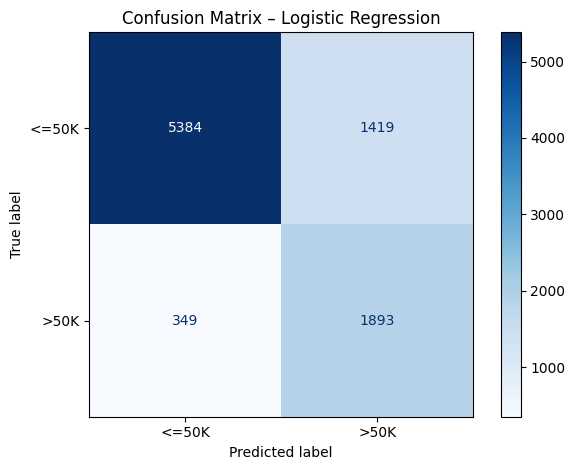

In [20]:
y_test_pred_lr  = lr_model.predict(X_test_sc)
y_test_proba_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression – Test Set ===")
print(classification_report(y_test, y_test_pred_lr, target_names=['<=50K', '>50K']))

test_metrics_lr = {
    'accuracy' : round(accuracy_score(y_test,  y_test_pred_lr),  4),
    'precision': round(precision_score(y_test, y_test_pred_lr),  4),
    'recall'   : round(recall_score(y_test,    y_test_pred_lr),  4),
    'f1'       : round(f1_score(y_test,        y_test_pred_lr),  4),
    'roc_auc'  : round(roc_auc_score(y_test,   y_test_proba_lr), 4),
}
print("Test metrics:", test_metrics_lr)

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp  = ConfusionMatrixDisplay(cm_lr, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

<!-- @format -->
# 4. MLP – Multi-Layer Perceptron

So sánh MLP với Logistic Regression baseline.

**Kiến trúc MLP:**
- Input layer → Hidden layers (BatchNorm → ReLU → Dropout) → Output (1 logit)
- Loss: `BCEWithLogitsLoss` với `pos_weight` để xử lý class imbalance còn lại trên val/test
- Optimizer: Adam + ReduceLROnPlateau scheduler
- Early stopping theo `val_loss`

<!-- @format -->
## 4.1. Setup device & DataLoaders

In [21]:
import importlib
import modules.deep_learning as dl
importlib.reload(dl)

import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Đóng gói dữ liệu đã preprocessing vào dict chuẩn của dl module
prep = {
    'X_train': X_train_sm.values.astype('float32'),
    'X_val'  : X_val_sc.values.astype('float32'),
    'X_test' : X_test_sc.values.astype('float32'),
    'y_train': y_train_sm.values.astype('int64'),
    'y_val'  : y_val.values.astype('int64'),
    'y_test' : y_test.values.astype('int64'),
    'input_dim': X_train_sm.shape[1],
}

train_loader, val_loader, test_loader = dl.create_dataloaders(prep, batch_size=256)

Using device: cpu
DataLoaders created  |  batch_size=256
  Train batches: 187  |  Val batches: 18  |  Test batches: 36


<!-- @format -->
## 4.2. MLP cơ bản [256, 128, 64]

In [22]:
model_mlp = dl.MLP(
    input_dim=prep['input_dim'],
    hidden_dims=[256, 128, 64],
    dropout=0.4,
)
print(model_mlp)
print(f"Tổng số tham số: {sum(p.numel() for p in model_mlp.parameters()):,}")

MLP(
  (net): Sequential(
    (linear_0): Linear(in_features=87, out_features=256, bias=True)
    (bn_0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_0): ReLU()
    (drop_0): Dropout(p=0.4, inplace=False)
    (linear_1): Linear(in_features=256, out_features=128, bias=True)
    (bn_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_1): ReLU()
    (drop_1): Dropout(p=0.4, inplace=False)
    (linear_2): Linear(in_features=128, out_features=64, bias=True)
    (bn_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_2): ReLU()
    (drop_2): Dropout(p=0.4, inplace=False)
    (output): Linear(in_features=64, out_features=1, bias=True)
  )
)
Tổng số tham số: 64,641


In [23]:
history_mlp = dl.train_model(
    model_mlp,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-3,
    patience=20,
    device=device,
    use_pos_weight=False,
)

use_pos_weight=False: BCEWithLogitsLoss không trọng số (train data đã cân bằng bằng SMOTE).
Training on cpu  |  epochs=100  |  lr=0.001  |  patience=20
----------------------------------------------------------------------
Epoch   1/100  |  train_loss=0.4090  train_acc=0.8123  |  val_loss=0.3785  val_acc=0.8085 *
Epoch   5/100  |  train_loss=0.3654  train_acc=0.8341  |  val_loss=0.4054  val_acc=0.8050
Epoch   7/100  |  train_loss=0.3643  train_acc=0.8332  |  val_loss=0.3625  val_acc=0.8161 *
Epoch  10/100  |  train_loss=0.3599  train_acc=0.8367  |  val_loss=0.3566  val_acc=0.8198 *
Epoch  15/100  |  train_loss=0.3546  train_acc=0.8371  |  val_loss=0.3906  val_acc=0.7950
Epoch  20/100  |  train_loss=0.3448  train_acc=0.8420  |  val_loss=0.4068  val_acc=0.7727
Epoch  25/100  |  train_loss=0.3355  train_acc=0.8473  |  val_loss=0.3902  val_acc=0.7973
Epoch  30/100  |  train_loss=0.3305  train_acc=0.8497  |  val_loss=0.3747  val_acc=0.8079

Early stopping at epoch 30 (best val_loss=0.3566)


<!-- @format -->
## 4.3. Learning Curves

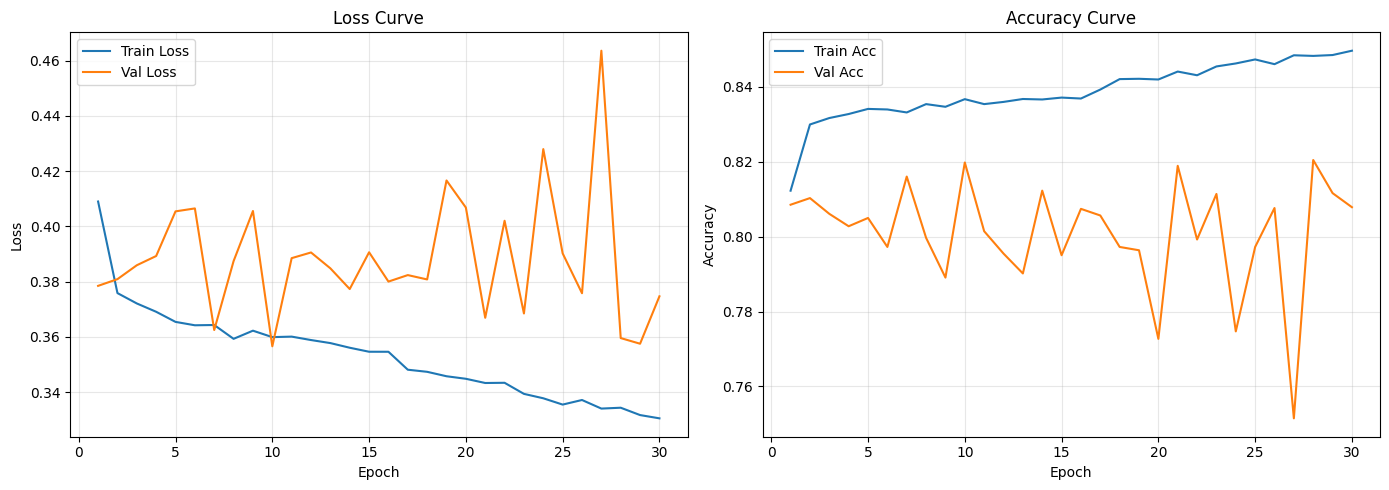

In [24]:
dl.plot_learning_curves(history_mlp)

<!-- @format -->
## 4.4. Đánh giá MLP trên Test set

=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      6803
        >50K       0.57      0.85      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.81      0.82      9045

Summary: {'accuracy': 0.8055, 'precision': 0.5725, 'recall': 0.8501, 'f1_score': 0.6843}


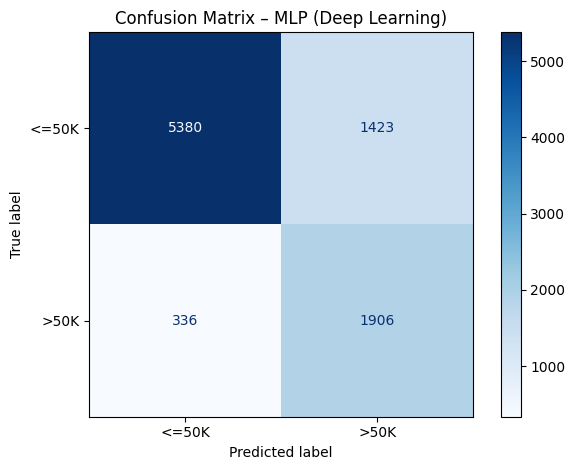

In [25]:
test_metrics_mlp, y_true_mlp, y_pred_mlp, y_proba_mlp = dl.evaluate_model(
    model_mlp, test_loader, device=device
)

<!-- @format -->
## 4.5. So sánh Logistic Regression vs MLP

In [26]:
import pandas as pd

compare = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP [256, 128, 64]',
        'Accuracy' : test_metrics_mlp['accuracy'],
        'Precision': test_metrics_mlp['precision'],
        'Recall'   : test_metrics_mlp['recall'],
        'F1-Score' : test_metrics_mlp['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_mlp, y_proba_mlp), 4),
    },
])

compare = compare.set_index('Model')
print(compare.to_string())
compare.style.highlight_max(axis=0, color='lightgreen')

                                Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                         
Logistic Regression (baseline)    0.8045     0.5716  0.8443    0.6817   0.9038
MLP [256, 128, 64]                0.8055     0.5725  0.8501    0.6843   0.9051


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804500,0.571600,0.844300,0.681700,0.903800
"MLP [256, 128, 64]",0.805500,0.572500,0.850100,0.684300,0.905100


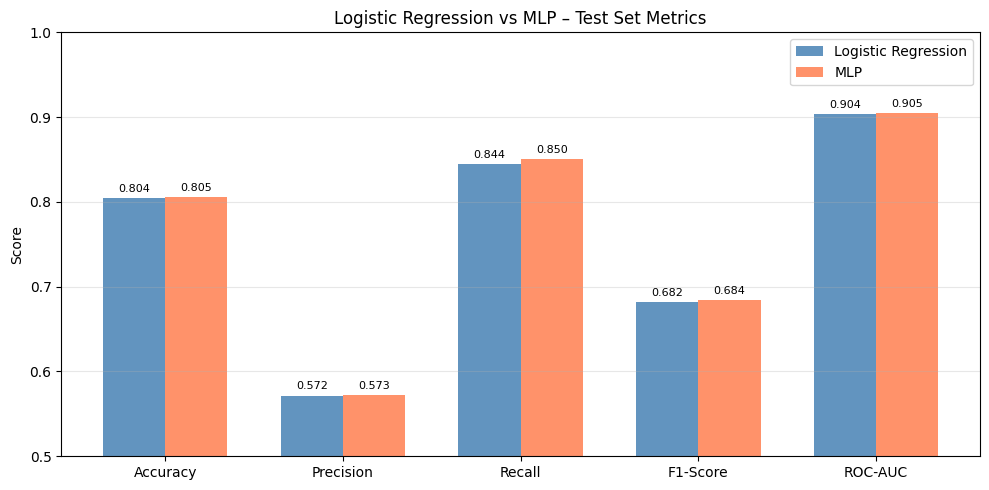

In [27]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare.loc['Logistic Regression (baseline)', metrics_to_plot],
               width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, compare.loc['MLP [256, 128, 64]', metrics_to_plot],
               width, label='MLP', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs MLP – Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Tối ưu hoá Siêu tham số với Optuna (Automatic Hyperparameter Tuning)

Tiếp theo, ta sử dụng thư viện **Optuna** đã được đóng gói trong file `modules/tuning_mlp.py` để thực hiện quá trình Auto-ML. Công cụ này sẽ tự động chạy thử nhiều cấu hình tham số khác nhau (số lớp, số node, lr, dropout, batch_size...) và tìm ra tập hợp trả về điểm **F1-Score** trên tập Validation cao nhất.

[I 2026-04-23 19:15:39,659] A new study created in memory with name: MLP-Adult-Income


Bắt đầu tìm kiếm tham số tối ưu bằng Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

DataLoaders created  |  batch_size=128
  Train batches: 248  |  Val batches: 36  |  Test batches: 71


Best trial: 0. Best value: 0.697887:   3%|▎         | 1/30 [00:45<22:08, 45.82s/it]

...

[I 2026-04-23 19:22:06,059] Trial 27 finished with value: 0.7009041591320072 and parameters: {'n_layers': 1, 'hidden_dim_0': 512, 'dropout': 0.5, 'lr': 0.0004700946567453747, 'weight_decay': 0.0006057719546135093, 'batch_size': 256, 'optimizer': 'Adam'}. Best is trial 22 with value: 0.7038782167451976.
DataLoaders created  |  batch_size=256
  Train batches: 124  |  Val batches: 18  |  Test batches: 36


Best trial: 22. Best value: 0.703878:  97%|█████████▋| 29/30 [06:32<00:10, 10.16s/it]

[I 2026-04-23 19:22:11,959] Trial 28 finished with value: 0.6995003568879372 and parameters: {'n_layers': 1, 'hidden_dim_0': 416, 'dropout': 0.45000000000000007, 'lr': 0.0023667951165316195, 'weight_decay': 0.0015646266884387157, 'batch_size': 256, 'optimizer': 'Adam'}. Best is trial 22 with value: 0.7038782167451976.
DataLoaders created  |  batch_size=256
  Train batches: 124  |  Val batches: 18  |  Test batches: 36


Best trial: 22. Best value: 0.703878: 100%|██████████| 30/30 [06:41<00:00, 13.39s/it]


[I 2026-04-23 19:22:21,497] Trial 29 finished with value: 0.7011412268188303 and parameters: {'n_layers': 2, 'hidden_dim_0': 256, 'hidden_dim_1': 320, 'dropout': 0.35, 'lr': 0.000836848091256386, 'weight_decay': 0.0001899764852183681, 'batch_size': 256, 'optimizer': 'Adam'}. Best is trial 22 with value: 0.7038782167451976.

  OPTUNA SEARCH COMPLETED  (30 trials)
  Best Val F1: 0.7039
  Best Params:
    n_layers: 1
    hidden_dim_0: 448
    dropout: 0.45000000000000007
    lr: 0.0006062520108287243
    weight_decay: 0.0011338218022458294
    batch_size: 256
    optimizer: Adam


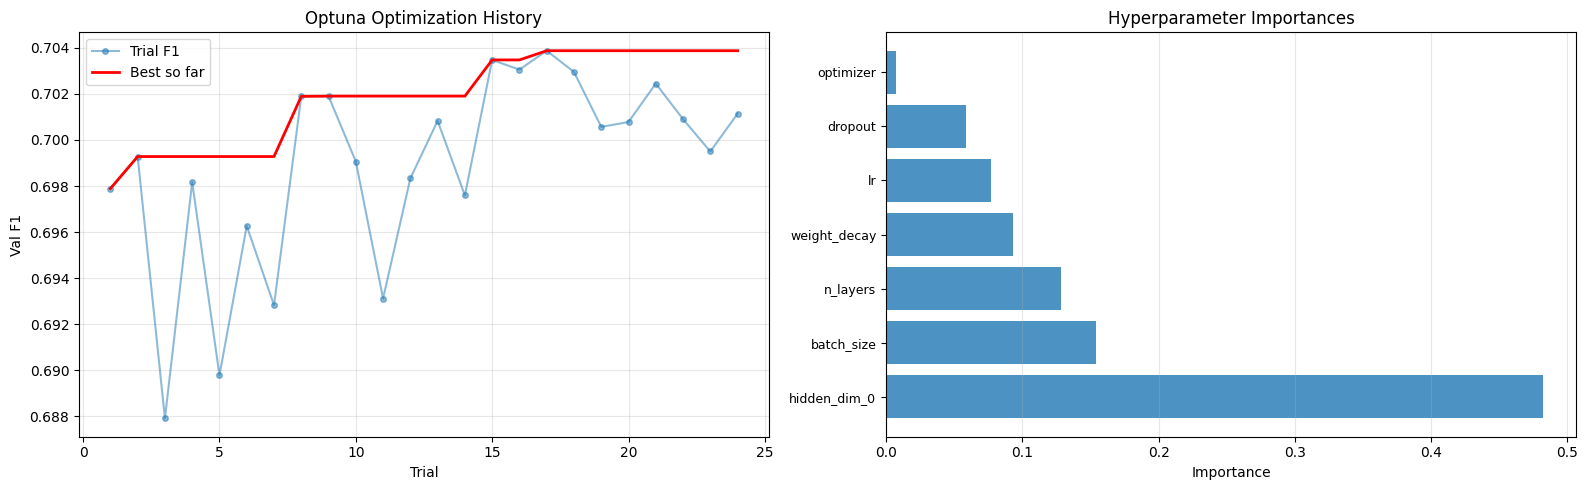

In [ ]:
import importlib
import modules.tuning_mlp as tune
importlib.reload(tune)

print("Bắt đầu tìm kiếm tham số tối ưu bằng Optuna...")
# Ở đây ta dùng bộ dữ liệu KHÔNG có SMOTE nhưng đã chuẩn hoá
prep_tuned = {
    'X_train': X_train_sc.values.astype('float32'),
    'X_val'  : X_val_sc.values.astype('float32'),
    'X_test' : X_test_sc.values.astype('float32'),
    'y_train': y_train.values.astype('int64'),
    'y_val'  : y_val.values.astype('int64'),
    'y_test' : y_test.values.astype('int64'),
    'input_dim': X_train_sc.shape[1],
}
train_loader_tuned, val_loader_tuned, test_loader_tuned = dl.create_dataloaders(prep_tuned, batch_size=256)

study_mlp = tune.run_optuna_search(
    prep=prep_tuned, 
    n_trials=30,  # Có thể tăng số lượng trial lên 50-100 nếu có nhiều thời gian (Tạm để 30 để chạy tốc hành)
    epochs=50, 
    patience=10, 
    device=device
)

# Trực quan hoá lịch sử tìm kiếm và độ quan trọng của các tham số
tune.plot_optuna_results(study_mlp)

Training best model: hidden_dims=[448], dropout=0.45000000000000007
  lr=0.000606, weight_decay=0.001134, batch_size=256, optimizer=Adam
DataLoaders created  |  batch_size=256
  Train batches: 124  |  Val batches: 18  |  Test batches: 36
Training on cpu  |  epochs=100  |  patience=15
----------------------------------------------------------------------
Epoch   1/100  |  train_loss=0.6375  train_acc=0.7856  |  val_loss=0.5651  val_acc=0.8167 *
Epoch   2/100  |  train_loss=0.5800  train_acc=0.8077  |  val_loss=0.5583  val_acc=0.8034 *
Epoch   3/100  |  train_loss=0.5760  train_acc=0.8062  |  val_loss=0.5531  val_acc=0.8103 *
Epoch   5/100  |  train_loss=0.5642  train_acc=0.8104  |  val_loss=0.5529  val_acc=0.8167 *
Epoch   8/100  |  train_loss=0.5583  train_acc=0.8096  |  val_loss=0.5502  val_acc=0.8156 *
Epoch  10/100  |  train_loss=0.5573  train_acc=0.8137  |  val_loss=0.5529  val_acc=0.8068
Epoch  15/100  |  train_loss=0.5507  train_acc=0.8155  |  val_loss=0.5518  val_acc=0.8183
Epoc

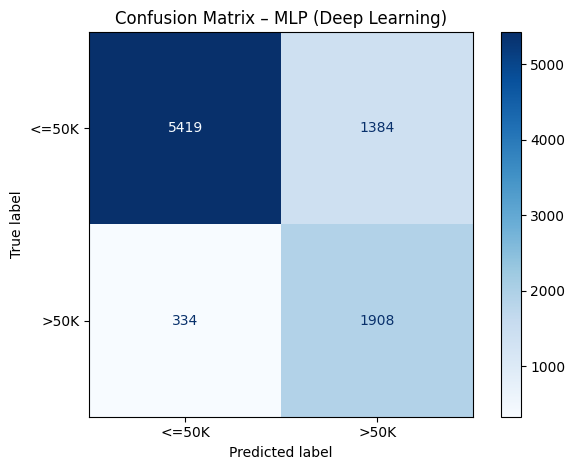

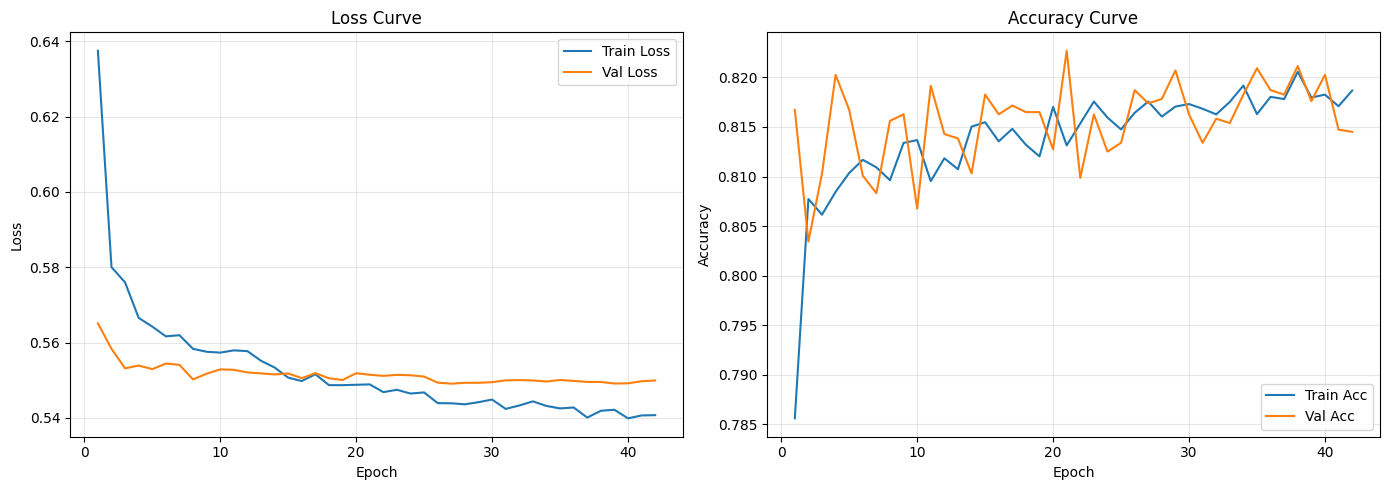

In [48]:
# 5.1. Huấn luyện lại và đánh giá mô hình bằng tham số đỉnh nhất (Best params)
best_model_optuna, best_history_optuna, best_metrics_optuna = tune.train_best_optuna_model(
    study=study_mlp,
    prep=prep_tuned,
    epochs=100,
    patience=15,
    device=device
)

# Vẽ lại learning curve của best model
dl.plot_learning_curves(best_history_optuna)

## 5.2. So sánh Logistic Regression vs MLP Optuna Best

=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      6803
        >50K       0.58      0.85      0.69      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.78      9045
weighted avg       0.85      0.81      0.82      9045

Summary: {'accuracy': 0.8101, 'precision': 0.5796, 'recall': 0.851, 'f1_score': 0.6896}


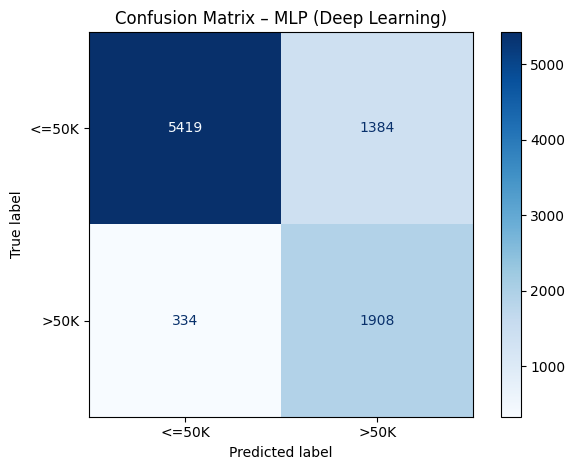

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804500,0.571600,0.844300,0.681700,0.903800
MLP (Optuna Best),0.810100,0.579600,0.851000,0.689600,0.910700


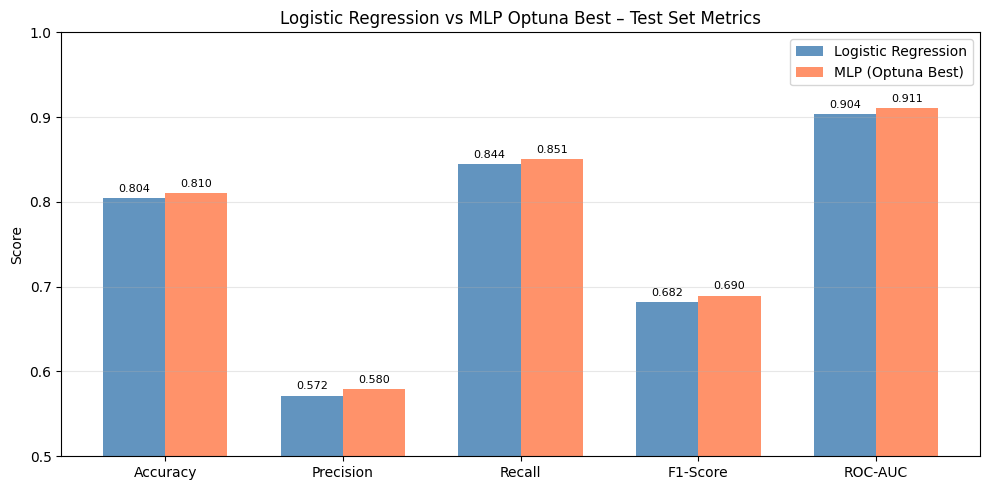

In [49]:
# Lấy dự đoán từ mô hình tốt nhất của Optuna để tính ROC-AUC
_, y_true_optuna, _, y_proba_optuna = dl.evaluate_model(best_model_optuna, test_loader_tuned, device=device)

compare_optuna = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP (Optuna Best)',
        'Accuracy' : best_metrics_optuna['accuracy'],
        'Precision': best_metrics_optuna['precision'],
        'Recall'   : best_metrics_optuna['recall'],
        'F1-Score' : best_metrics_optuna['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_optuna, y_proba_optuna), 4),
    },
])

compare_optuna = compare_optuna.set_index('Model')
display(compare_optuna.style.highlight_max(axis=0, color='lightgreen'))

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare_optuna.loc['Logistic Regression (baseline)', metrics_to_plot],
               width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, compare_optuna.loc['MLP (Optuna Best)', metrics_to_plot],
               width, label='MLP (Optuna Best)', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs MLP Optuna Best – Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. TabNet Model (Attentive Interpretable Tabular Learning)

Sử dụng kiến trúc TabNet được tối ưu hóa đặc biệt cho dữ liệu dạng bảng.
Nhóm quyết định **KHÔNG sử dụng SMOTE** cho TabNet vì mô hình này yêu cầu giữ nguyên tính chất của các biến phân loại (để đưa qua lớp embedding layer) thay vì ép sang dạng One-Hot liên tục sinh bởi SMOTE.

In [50]:
# 1. Gọi hàm tiền xử lý dữ liệu tự động cho TabNet từ module có sẵn
import importlib
import modules.deep_learning as dl
importlib.reload(dl) # Reload lại module để nhận code mới nhất từ file .py

import numpy as np

print("--- Chuẩn bị Data gốc cho TabNet ---")
# Đầu vào là df_clean (dataset chuẩn bị ở bước 2.2, chưa qua encode hay smote)
prep_tabnet = dl.preprocess_for_tabnet(
    df_clean, 
    target_col='income', 
    random_state=42
)

print("\nShape của dữ liệu train TabNet (số + phân loại đã mã hóa số nguyên):", prep_tabnet['X_train'].shape)

--- Chuẩn bị Data gốc cho TabNet ---
Rare category grouping (threshold=0.01):
  workclass: 1 rare → 'Other'  (kept 7 categories)
  marital-status: 1 rare → 'Other'  (kept 7 categories)
  occupation: 2 rare → 'Other'  (kept 13 categories)
  race: 2 rare → 'Other'  (kept 4 categories)
  native-country: 39 rare → 'Other'  (kept 3 categories)
  Total rare categories grouped: 45
Encoding mode: TabNet integer categorical + internal embeddings
Num features: 3 | Cat features: 9
cat_idxs: [3, 4, 5, 6, 7, 8, 9, 10, 11]
cat_dims: [8, 8, 14, 7, 5, 3, 4, 5, 4]

Shape của dữ liệu train TabNet (số + phân loại đã mã hóa số nguyên): (28941, 12)


In [51]:
# 2. Đào tạo mô hình TabNet

print("\n--- Bắt đầu Training TabNet ---")
tabnet_model = dl.train_tabnet_model(
    prep=prep_tabnet,
    n_d=32,               # Kích thước lớp quyết định
    n_a=32,               # Kích thước lớp chú ý
    n_steps=3,            # Số chặng Attention
    gamma=1.3,
    lr=2e-2,
    max_epochs=100,       
    patience=15,          # Dừng sớm nếu sau 15 epoch val loss không giảm
    batch_size=512,
    virtual_batch_size=128,
    device=device
)


--- Bắt đầu Training TabNet ---
TabNet class weights: {0: 0.6647601984564498, 1: 2.017356754496027}


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.52607 | val_logloss: 1.66226 |  0:00:01s
epoch 1  | loss: 0.44296 | val_logloss: 0.91441 |  0:00:03s
epoch 2  | loss: 0.42004 | val_logloss: 0.49866 |  0:00:05s
epoch 3  | loss: 0.41441 | val_logloss: 0.52867 |  0:00:06s
epoch 4  | loss: 0.4025  | val_logloss: 0.44568 |  0:00:08s
epoch 5  | loss: 0.39922 | val_logloss: 0.40439 |  0:00:09s
epoch 6  | loss: 0.3941  | val_logloss: 0.40259 |  0:00:11s
epoch 7  | loss: 0.39348 | val_logloss: 0.41476 |  0:00:12s
epoch 8  | loss: 0.39263 | val_logloss: 0.43005 |  0:00:14s
epoch 9  | loss: 0.38658 | val_logloss: 0.40167 |  0:00:15s
epoch 10 | loss: 0.38496 | val_logloss: 0.42508 |  0:00:17s
epoch 11 | loss: 0.38241 | val_logloss: 0.39932 |  0:00:18s
epoch 12 | loss: 0.38519 | val_logloss: 0.38615 |  0:00:20s
epoch 13 | loss: 0.38488 | val_logloss: 0.42747 |  0:00:21s
epoch 14 | loss: 0.38411 | val_logloss: 0.36823 |  0:00:22s
epoch 15 | loss: 0.38427 | val_logloss: 0.43398 |  0:00:24s
epoch 16 | loss: 0.38805 | val_logloss: 

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet training complete. Best epoch: 27


=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.93      0.81      0.87      6803
        >50K       0.59      0.82      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.78      9045
weighted avg       0.85      0.81      0.82      9045

Summary: {'accuracy': 0.8118, 'precision': 0.5856, 'recall': 0.8243, 'f1_score': 0.6847}


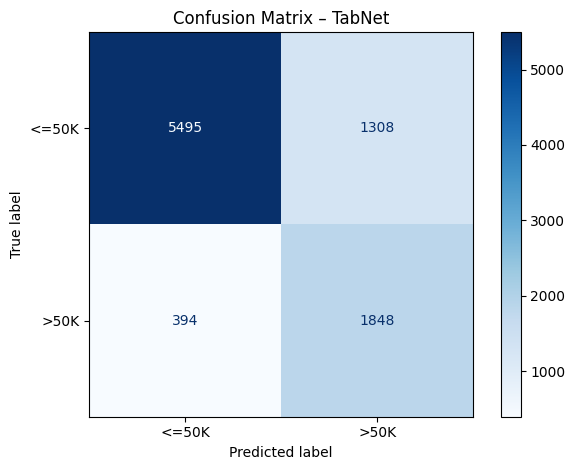

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804500,0.571600,0.844300,0.681700,0.903800
MLP (Optuna Best),0.810100,0.579600,0.851000,0.689600,0.910700
TabNet Basic (No SMOTE),0.811800,0.585600,0.824300,0.684700,0.903400


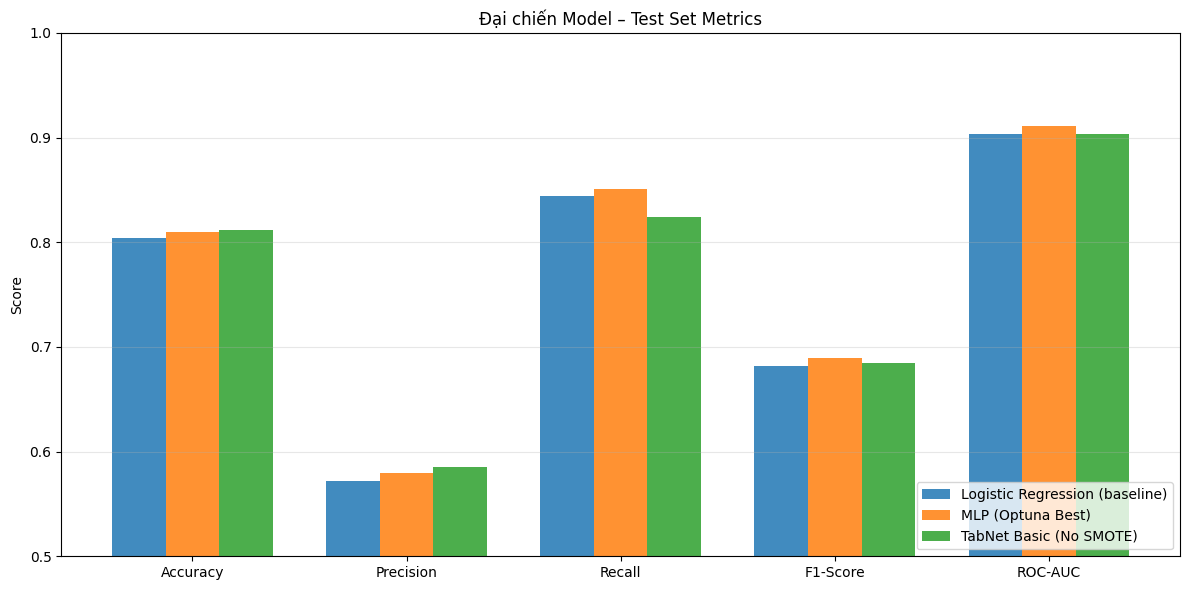

In [52]:
# 3. Đánh giá và So sánh lại với các Baseline trước đó
metrics_tabnet, y_true_tabnet, y_pred_tabnet, y_proba_tabnet = dl.evaluate_tabnet(tabnet_model, prep_tabnet)

compare_all = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP (Optuna Best)',
        'Accuracy' : best_metrics_optuna['accuracy'],
        'Precision': best_metrics_optuna['precision'],
        'Recall'   : best_metrics_optuna['recall'],
        'F1-Score' : best_metrics_optuna['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_optuna, y_proba_optuna), 4),
    },
    {
        'Model'    : 'TabNet Basic (No SMOTE)',
        'Accuracy' : metrics_tabnet['accuracy'],
        'Precision': metrics_tabnet['precision'],
        'Recall'   : metrics_tabnet['recall'],
        'F1-Score' : metrics_tabnet['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_tabnet, y_proba_tabnet), 4),
    },
])

compare_all = compare_all.set_index('Model')
display(compare_all.style.highlight_max(axis=0, color='lightgreen'))

# Trực quan hoá
fig, ax = plt.subplots(figsize=(12, 6))
width_new = 0.25
for i, model_name in enumerate(compare_all.index):
    ax.bar(x + (i - 1) * width_new, compare_all.loc[model_name, metrics_to_plot],
           width_new, label=model_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Đại chiến Model – Test Set Metrics')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Tối ưu hoá Siêu tham số TabNet với Optuna

Chúng ta sẽ sử dụng các hàm đã được gói sẵn trong `modules/tuning_mlp.py` để tìm kiếm siêu tham số và huấn luyện mô hình TabNet tốt nhất. Đặc biệt ở đây còn kèm theo **Cơ chế Pretraining (Self-supervised learning)** tích hợp sẵn.

In [53]:
import modules.tuning_mlp as tune
import importlib
importlib.reload(tune)

# 7.1 Thực hiện dò TabNet params
# Sử dụng hàm dò Optuna có sẵn của bạn trong tuning_mlp.py (Đã bật use_pretraining=True mặc định)
study_tabnet = tune.run_optuna_search_tabnet(
    prep_tabnet=prep_tabnet,
    n_trials=10, 
    max_epochs=50,
    patience=10,
    device=device,
    use_pretraining=True # Sử dụng pretrain tích hợp sẵn
)

[I 2026-04-23 19:26:38,286] A new study created in memory with name: TabNet-Adult-Income-Pretrain


  0%|          | 0/10 [00:00<?, ?it/s]/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.69346 | val_unsup_loss_numpy: 0.9640700221061707|  0:00:04s
epoch 1  | loss: 0.97375 | val_unsup_loss_numpy: 0.882830023765564|  0:00:09s
epoch 2  | loss: 0.9658  | val_unsup_loss_numpy: 0.8626000285148621|  0:00:13s
epoch 3  | loss: 0.95965 | val_unsup_loss_numpy: 0.8832600116729736|  0:00:18s
epoch 4  | loss: 0.9592  | val_unsup_loss_numpy: 0.8288900256156921|  0:00:23s
epoch 5  | loss: 0.95757 | val_unsup_loss_numpy: 0.8478099703788757|  0:00:27s
epoch 6  | loss: 0.95893 | val_unsup_loss_numpy: 0.8062800168991089|  0:00:31s
epoch 7  | loss: 0.95356 | val_unsup_loss_numpy: 0.8191099762916565|  0:00:35s
epoch 8  | loss: 0.95253 | val_unsup_loss_numpy: 0.7967100143432617|  0:00:39s
epoch 9  | loss: 0.95539 | val_unsup_loss_numpy: 0.8052099943161011|  0:00:43s
epoch 10 | loss: 0.95126 | val_unsup_loss_numpy: 0.8200899958610535|  0:00:48s
epoch 11 | loss: 0.94747 | val_unsup_loss_numpy: 0.8207399845123291|  0:00:52s
epoch 12 | loss: 0.94963 | val_unsup_loss_numpy: 0.79

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 0.54236 | val_logloss: 0.70347 |  0:00:02s
epoch 1  | loss: 0.43655 | val_logloss: 0.43719 |  0:00:04s
epoch 2  | loss: 0.41584 | val_logloss: 0.44752 |  0:00:06s
epoch 3  | loss: 0.40655 | val_logloss: 0.48437 |  0:00:09s
epoch 4  | loss: 0.40518 | val_logloss: 0.38958 |  0:00:11s
epoch 5  | loss: 0.40917 | val_logloss: 0.38378 |  0:00:13s
epoch 6  | loss: 0.39974 | val_logloss: 0.42065 |  0:00:16s
epoch 7  | loss: 0.39627 | val_logloss: 0.44433 |  0:00:18s
epoch 8  | loss: 0.39713 | val_logloss: 0.39328 |  0:00:20s
epoch 9  | loss: 0.39254 | val_logloss: 0.42341 |  0:00:22s
epoch 10 | loss: 0.38765 | val_logloss: 0.42933 |  0:00:25s
epoch 11 | loss: 0.38491 | val_logloss: 0.39184 |  0:00:27s
epoch 12 | loss: 0.38913 | val_logloss: 0.4013  |  0:00:29s
epoch 13 | loss: 0.39006 | val_logloss: 0.36775 |  0:00:31s
epoch 14 | loss: 0.38558 | val_logloss: 0.41013 |  0:00:33s
epoch 15 | loss: 0.38525 | val_logloss: 0.45054 |  0:00:35s
epoch 16 | loss: 0.39215 | val_logloss: 

...

epoch 0  | loss: 3.51843 | val_unsup_loss_numpy: 1.297950029373169|  0:00:02s
epoch 1  | loss: 0.97442 | val_unsup_loss_numpy: 1.0514999628067017|  0:00:04s
epoch 2  | loss: 0.93587 | val_unsup_loss_numpy: 1.0471800565719604|  0:00:07s
epoch 3  | loss: 0.92501 | val_unsup_loss_numpy: 0.8066400289535522|  0:00:09s
epoch 4  | loss: 0.89924 | val_unsup_loss_numpy: 0.7984499931335449|  0:00:11s
epoch 5  | loss: 0.89359 | val_unsup_loss_numpy: 0.7751100063323975|  0:00:14s
epoch 6  | loss: 0.8876  | val_unsup_loss_numpy: 0.8189100027084351|  0:00:17s
epoch 7  | loss: 0.88481 | val_unsup_loss_numpy: 0.7796599864959717|  0:00:19s
epoch 8  | loss: 0.88648 | val_unsup_loss_numpy: 0.7643300294876099|  0:00:21s
epoch 9  | loss: 0.87821 | val_unsup_loss_numpy: 0.788640022277832|  0:00:24s
epoch 10 | loss: 0.87808 | val_unsup_loss_numpy: 0.7766900062561035|  0:00:26s
epoch 11 | loss: 0.88493 | val_unsup_loss_numpy: 0.7849599719047546|  0:00:29s
epoch 12 | loss: 0.88638 | val_unsup_loss_numpy: 0.764

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 0.59251 | val_logloss: 0.64266 |  0:00:01s
epoch 1  | loss: 0.4491  | val_logloss: 0.4693  |  0:00:02s
epoch 2  | loss: 0.4348  | val_logloss: 0.47746 |  0:00:04s
epoch 3  | loss: 0.42208 | val_logloss: 0.51874 |  0:00:05s
epoch 4  | loss: 0.41544 | val_logloss: 0.50771 |  0:00:06s
epoch 5  | loss: 0.41304 | val_logloss: 0.46927 |  0:00:08s
epoch 6  | loss: 0.4063  | val_logloss: 0.41229 |  0:00:09s
epoch 7  | loss: 0.4023  | val_logloss: 0.46313 |  0:00:11s
epoch 8  | loss: 0.39373 | val_logloss: 0.42259 |  0:00:12s
epoch 9  | loss: 0.38845 | val_logloss: 0.41341 |  0:00:13s
epoch 10 | loss: 0.38671 | val_logloss: 0.38607 |  0:00:15s
epoch 11 | loss: 0.39154 | val_logloss: 0.43743 |  0:00:16s
epoch 12 | loss: 0.40103 | val_logloss: 0.35577 |  0:00:18s
epoch 13 | loss: 0.39968 | val_logloss: 0.37992 |  0:00:19s
epoch 14 | loss: 0.39419 | val_logloss: 0.38622 |  0:00:20s
epoch 15 | loss: 0.39733 | val_logloss: 0.4077  |  0:00:22s
epoch 16 | loss: 0.38723 | val_logloss: 

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
Best trial: 6. Best value: 0.689252: 100%|██████████| 10/10 [25:09<00:00, 150.98s/it]

TabNet training complete. Best epoch: 12
[I 2026-04-23 19:51:48,139] Trial 9 finished with value: 0.68472049689441 and parameters: {'width': 32, 'n_steps': 4, 'gamma': 1.3918469083831662, 'lambda_sparse': 0.0006947115281312545, 'lr': 0.02857701150035981, 'batch_size': 1024, 'virtual_batch_size': 256, 'pretrain_epochs': 20, 'pretraining_ratio': 0.639144603268195}. Best is trial 6 with value: 0.6892517669997563.

  TABNET OPTUNA SEARCH COMPLETED  (10 trials)
  Best Val F1: 0.6893
  Best Params:
    width: 32
    n_steps: 5
    gamma: 1.1567756619884113
    lambda_sparse: 0.0002470075927278519
    lr: 0.005103987214345484
    batch_size: 256
    virtual_batch_size: 128
    pretrain_epochs: 60
    pretraining_ratio: 0.7319236798550977


/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 5.03844 | val_unsup_loss_numpy: 1.8616900444030762|  0:00:05s
epoch 1  | loss: 1.00474 | val_unsup_loss_numpy: 1.4545300006866455|  0:00:11s
epoch 2  | loss: 0.96166 | val_unsup_loss_numpy: 1.074139952659607|  0:00:17s
epoch 3  | loss: 0.95554 | val_unsup_loss_numpy: 1.0319000482559204|  0:00:22s
epoch 4  | loss: 0.94305 | val_unsup_loss_numpy: 1.0849599838256836|  0:00:28s
epoch 5  | loss: 0.92326 | val_unsup_loss_numpy: 1.0263099670410156|  0:00:33s
epoch 6  | loss: 0.92928 | val_unsup_loss_numpy: 0.9564899802207947|  0:00:38s
epoch 7  | loss: 0.92088 | val_unsup_loss_numpy: 0.9396499991416931|  0:00:42s
epoch 8  | loss: 0.92644 | val_unsup_loss_numpy: 0.9092900156974792|  0:00:47s
epoch 9  | loss: 0.91499 | val_unsup_loss_numpy: 0.8696399927139282|  0:00:52s
epoch 10 | loss: 0.91692 | val_unsup_loss_numpy: 0.8435999751091003|  0:00:57s
epoch 11 | loss: 0.91785 | val_unsup_loss_numpy: 0.806439995765686|  0:01:02s
epoch 12 | loss: 0.91061 | val_unsup_loss_numpy: 0.802

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 0.60527 | val_logloss: 0.53046 |  0:00:02s
epoch 1  | loss: 0.43811 | val_logloss: 0.43922 |  0:00:05s
epoch 2  | loss: 0.42496 | val_logloss: 0.40765 |  0:00:07s
epoch 3  | loss: 0.41241 | val_logloss: 0.41064 |  0:00:10s
epoch 4  | loss: 0.40848 | val_logloss: 0.4156  |  0:00:13s
epoch 5  | loss: 0.4026  | val_logloss: 0.419   |  0:00:16s
epoch 6  | loss: 0.40275 | val_logloss: 0.41032 |  0:00:19s
epoch 7  | loss: 0.40356 | val_logloss: 0.44358 |  0:00:21s
epoch 8  | loss: 0.39309 | val_logloss: 0.38742 |  0:00:24s
epoch 9  | loss: 0.39391 | val_logloss: 0.42083 |  0:00:26s
epoch 10 | loss: 0.38806 | val_logloss: 0.39637 |  0:00:29s
epoch 11 | loss: 0.40051 | val_logloss: 0.42653 |  0:00:31s
epoch 12 | loss: 0.39351 | val_logloss: 0.4185  |  0:00:34s
epoch 13 | loss: 0.39742 | val_logloss: 0.41651 |  0:00:37s
epoch 14 | loss: 0.39479 | val_logloss: 0.38948 |  0:00:39s
epoch 15 | loss: 0.39376 | val_logloss: 0.37513 |  0:00:42s
epoch 16 | loss: 0.39383 | val_logloss: 

/opt/anaconda3/envs/ml-env/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet training complete. Best epoch: 16
=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.92      0.83      0.87      6803
        >50K       0.60      0.78      0.68      2242

    accuracy                           0.82      9045
   macro avg       0.76      0.80      0.77      9045
weighted avg       0.84      0.82      0.82      9045

Summary: {'accuracy': 0.8165, 'precision': 0.6002, 'recall': 0.7774, 'f1_score': 0.6774}


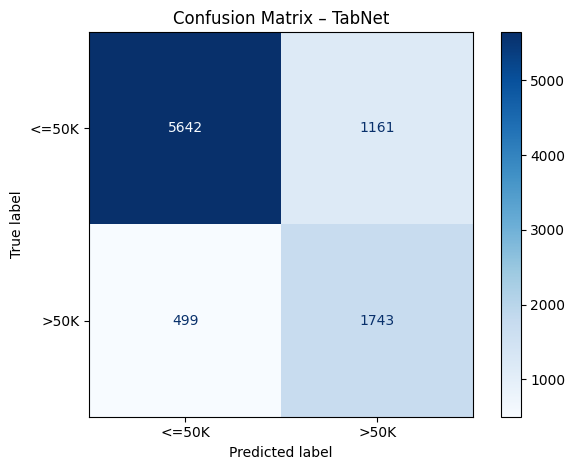

=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.92      0.83      0.87      6803
        >50K       0.60      0.78      0.68      2242

    accuracy                           0.82      9045
   macro avg       0.76      0.80      0.77      9045
weighted avg       0.84      0.82      0.82      9045

Summary: {'accuracy': 0.8165, 'precision': 0.6002, 'recall': 0.7774, 'f1_score': 0.6774}


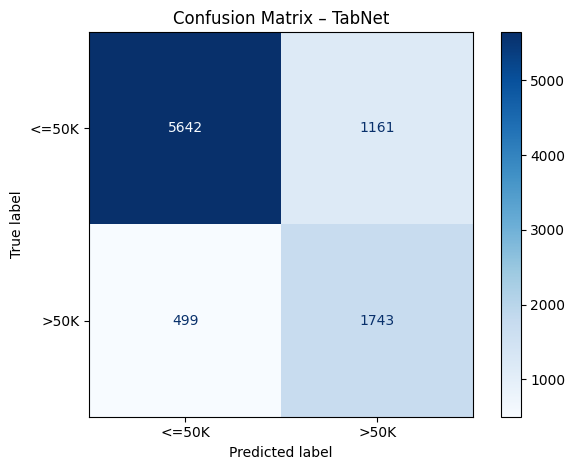

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804500,0.571600,0.844300,0.681700,0.903800
MLP (Optuna Best),0.810100,0.579600,0.851000,0.689600,0.910700
TabNet Basic (No SMOTE),0.811800,0.585600,0.824300,0.684700,0.903400
TabNet (Optuna Best),0.816500,0.600200,0.777400,0.677400,0.897600


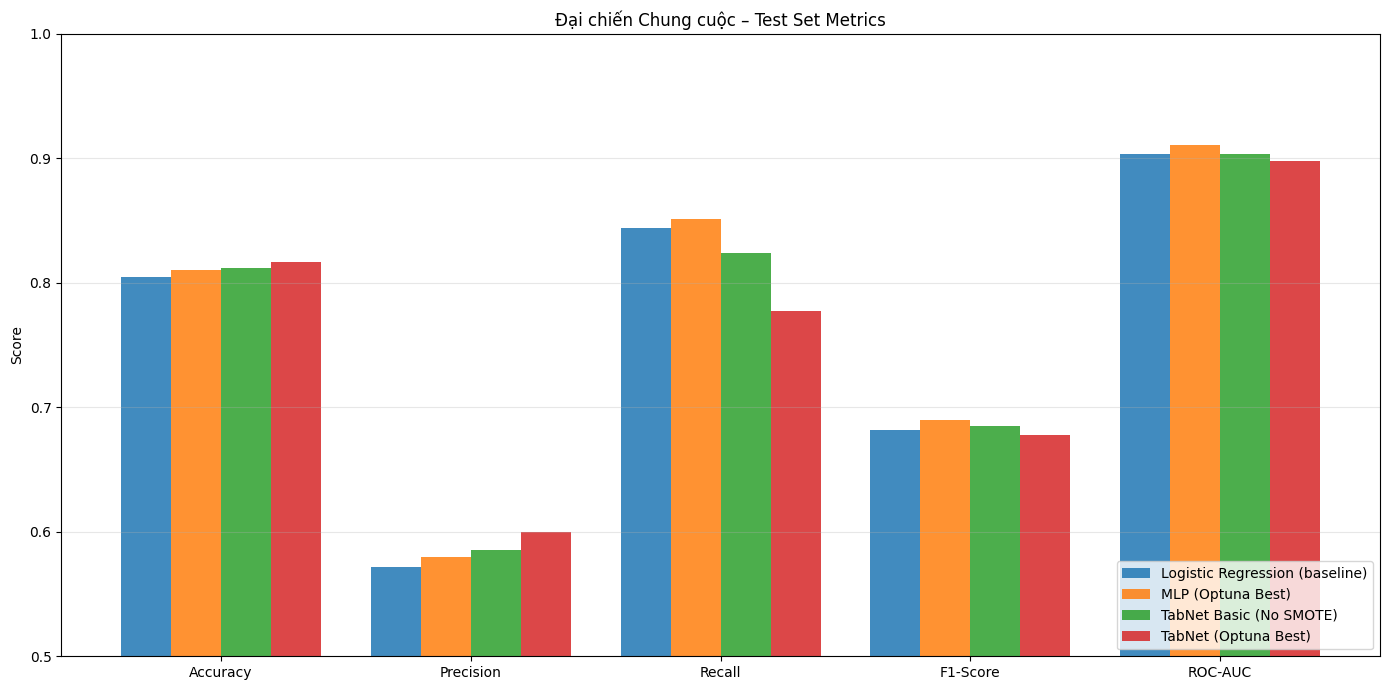

In [54]:
# 7.2 Lấy mô hình có cấu hình tốt nhất và trong tuning_mlp.py
# Hàm `train_best_optuna_tabnet_model` sẽ trả về (model, metrics) nên ta lấy cả hai
best_tabnet_optuna, metrics_tabnet_best = tune.train_best_optuna_tabnet_model(
    study=study_tabnet, 
    prep_tabnet=prep_tabnet, 
    max_epochs=100, 
    patience=15, 
    device=device,
    use_pretraining=True
)

# Để lấy phân loại ROC-AUC, ta dùng predict_proba hoặc chạy lại evaluate
_, y_true_tb, y_pred_tb, y_proba_tb = dl.evaluate_tabnet(best_tabnet_optuna, prep_tabnet)

compare_all.loc['TabNet (Optuna Best)'] = [
    metrics_tabnet_best['accuracy'],
    metrics_tabnet_best['precision'],
    metrics_tabnet_best['recall'],
    metrics_tabnet_best['f1_score'],
    round(roc_auc_score(y_true_tb, y_proba_tb), 4)
]

display(compare_all.style.highlight_max(axis=0, color='lightgreen'))

# Trực quan hoá bản chốt hạ cuối
fig, ax = plt.subplots(figsize=(14, 7))
width_new = 0.2
for i, model_name in enumerate(compare_all.index):
    # Dịch chuyển vị trí các cột
    ax.bar(x + (i - 1.5) * width_new, compare_all.loc[model_name, metrics_to_plot],
           width_new, label=model_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Đại chiến Chung cuộc – Test Set Metrics')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()